# Text preprocessing, bag of words, and TF-IDF

### Turning documents into rows of numbers a classifier can read

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com) ·
[all notebooks](../../CURRICULUM.md)

---

| | |
|---|---|
| **What you will learn** | How a document becomes a row of numbers, why raw counts over-weight the commonest words, the TF-IDF formula written out and computed by hand, what n-grams add, and which of `min_df` / `max_df` / `max_features` actually change anything |
| **You should already know** | [Logistic regression](../../03-classification/01-logistic-regression/), [train and test splits](../../01-foundations/03-overfitting-and-underfitting/) |
| **Dataset** | 20 Newsgroups, three groups. If the download is unavailable the notebook builds its own stand-in corpus and everything below still runs |
| **Runtime** | Two to three minutes on a laptop CPU |
| **Next** | [09-02 Word embeddings: Word2Vec and GloVe](../02-word-embeddings/) |

---

## 1. The idea

Every model in this book so far wanted a matrix: one row per example, one column
per feature, numbers in the cells. Text does not arrive that way. It arrives as
a string of characters of no fixed length.

The oldest working answer is to throw away word order and count. Fix a
vocabulary of $V$ words, and represent a document as a vector of length $V$
holding how many times each word appeared. A corpus of $n$ documents becomes an
$n \times V$ matrix, and every model you already know accepts it.

That is the **bag of words**. The name is the honest description: you tip the
document into a bag, shake it, and keep only which words fell out and how often.
"The dog bit the man" and "the man bit the dog" become the same vector. Losing
that seems fatal until you measure it, and on topic classification it costs
almost nothing, because topics live in which words appear rather than in which
order.

Two things go wrong with plain counting, and the rest of this notebook is about
them. The first is that the commonest words dominate every vector while telling
you nothing — that is what TF-IDF fixes. The second is that some meaning really
does live in adjacent pairs — that is what n-grams recover.

In [1]:
import sys
import pathlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
            if (p / "toolkit").is_dir())
sys.path.insert(0, str(ROOT))

from toolkit import style

style.use()
FIG = pathlib.Path("figures")
SEED = 0

### The corpus

I use three groups from 20 Newsgroups: computer graphics, baseball, and space.
Three topics that a human separates instantly, with enough shared English
between them that the vectoriser has to do real work.

`scikit-learn` downloads that dataset on first use and caches it. There is no
text file in this repository's toolkit, so if the download fails — offline
machine, blocked network, CI runner with no egress — the next cell builds a
stand-in corpus from sentence templates instead. Same three topics, same
variable names afterwards, every figure and every number below still produced.
The printed line tells you which path ran.

`remove=("headers", "footers", "quotes")` strips the email headers, the
signatures, and the quoted reply text. Without it the classifier learns to read
the `Organization:` line and scores far too well for the wrong reason.

In [2]:
import socket

from sklearn.datasets import fetch_20newsgroups
from sklearn.model_selection import train_test_split

CATEGORIES = ["comp.graphics", "rec.sport.baseball", "sci.space"]
LABELS = ["graphics", "baseball", "space"]

# Sentence pools for the stand-in corpus. Written by hand so the vocabulary looks
# like real posts; assembled by numpy so there are enough documents to train on.
TOPIC_SENTENCES = {
    "graphics": [
        "does anyone know a library for converting a {thing} file on a unix box",
        "i am looking for source code that renders shaded polygons in real time",
        "the ray tracer produces lovely images but it takes hours for one frame",
        "you need a twenty four bit display or the dithering will ruin the colours",
        "i have a large pile of {thing} images and no viewer that will read them",
        "the algorithm computes the intersection of a ray with a triangle mesh",
        "anti aliasing removes the jagged steps along the diagonal lines",
        "can someone point me at the jpeg compression standard document",
        "the graphics card has two megabytes of video memory which is not enough",
        "i wrote a small program that converts between rgb and hsv colour spaces",
        "texture mapping onto a curved surface is harder than it first looks",
        "the postscript output is fine on screen but the printer drops the shading",
        "does the package support bezier curves or only straight line segments",
        "the frame buffer is one byte per pixel with a palette lookup on the way out",
        "i need an image format that keeps an alpha channel for transparency",
        "the polygon count went up and the frame rate went straight down",
        "we use a z buffer to decide which surface is visible at each pixel",
        "the scanner software writes a proprietary format that nothing else reads",
    ],
    "baseball": [
        "the pitcher threw ninety eight pitches and still had something in the eighth",
        "he is batting three hundred since the all star break and it is no accident",
        "the manager pulled the starter early and the bullpen gave the lead away",
        "our shortstop has the best glove in the league and cannot hit at all",
        "the {thing} lost four straight at home and the season is basically over",
        "a runner on second with nobody out and they still could not score him",
        "the umpire missed the call at first base and everyone in the park saw it",
        "his earned run average looks fine until you count how few innings he pitched",
        "the trade deadline is coming and we badly need a left handed reliever",
        "he hit a home run to the opposite field off a fastball up and in",
        "the rookie catcher is throwing out runners at a rate nobody expected",
        "batting average tells you less than on base percentage and people still quote it",
        "the double play ended the inning and the crowd finally sat back down",
        "spring training numbers mean nothing and every year people forget that",
        "he stole second and then third on consecutive pitches",
        "the outfield wall is short in left which flatters right handed power",
        "a rotation of five starters is fine until two of them get hurt in june",
        "the game went fourteen innings and both teams ran out of pitchers",
    ],
    "space": [
        "the launch window opens next month and the payload is already at the cape",
        "a low earth orbit costs far less to reach than a geostationary one",
        "the shuttle carried a crew of seven and a laboratory in the cargo bay",
        "solar panels degrade slowly and the power budget has to allow for it",
        "the probe will take a gravity assist at {thing} before it heads outward",
        "escape velocity from the surface is about eleven kilometres per second",
        "the telescope mirror was ground to the wrong shape and nobody caught it",
        "a station in orbit needs shielding against radiation and micrometeorites",
        "the rocket engine burns liquid oxygen and hydrogen at enormous pressure",
        "reentry heating is the hard part rather than getting up there at all",
        "the mission was cancelled after the budget was cut in committee",
        "an ion drive gives tiny thrust for months instead of huge thrust for minutes",
        "the orbit decayed and the satellite burned up somewhere over the pacific",
        "we heard the signal from the spacecraft eight hours after the burn",
        "the lander survived the descent and returned images on the same day",
        "a launch failure destroyed the payload thirty seconds after liftoff",
        "the astronauts spent six hours outside the airlock replacing the module",
        "the trajectory correction used less fuel than the flight plan allowed",
    ],
}

SHARED_SENTENCES = [
    "i have been reading this group for a while and finally have something to add",
    "thanks in advance for any help and please reply by mail if you prefer",
    "sorry if this has been asked before but the archive search is down again",
    "i am not an expert here so take what follows with a grain of salt",
    "does anyone have a reference for this or am i remembering it wrong",
    "that is the first sensible thing anyone has posted in this group all week",
    "i disagree with almost everything in the message i am replying to",
    "the numbers in that article do not match the ones i have seen elsewhere",
    "any pointers to books or papers on this would be appreciated",
    "this has been discussed to death but here is my opinion anyway",
    "please do not post the same question three times in one day",
    "i will summarise the replies i get and post them next week",
]

FILLERS = {
    "graphics": ["gif", "tiff", "targa", "pcx", "sun raster", "iff"],
    "baseball": ["red sox", "cubs", "mets", "braves", "tigers", "expos"],
    "space": ["jupiter", "venus", "mars", "the moon", "saturn"],
}


def build_stand_in(n_per_class=220, seed=SEED):
    """Assemble documents by drawing sentences: mostly on-topic, some generic.

    The generic pool is what makes the problem non-trivial. Without it every
    document is separable by a single word and the vectoriser comparison at the
    end has nothing to measure.
    """
    rng = np.random.default_rng(seed)
    docs, labels = [], []
    for class_index, name in enumerate(LABELS):
        for _ in range(n_per_class):
            picked = []
            for _ in range(int(rng.integers(3, 6))):
                roll = rng.random()
                if roll < 0.62:
                    topic = name
                elif roll < 0.88:
                    topic = None
                else:
                    topic = LABELS[int(rng.integers(0, len(LABELS)))]
                if topic is None:
                    sentence = SHARED_SENTENCES[int(rng.integers(0, len(SHARED_SENTENCES)))]
                else:
                    pool = TOPIC_SENTENCES[topic]
                    sentence = pool[int(rng.integers(0, len(pool)))]
                    fill = FILLERS[topic]
                    sentence = sentence.replace("{thing}", fill[int(rng.integers(0, len(fill)))])
                picked.append(sentence)
            docs.append(". ".join(picked) + ".")
            labels.append(class_index)
    return docs, np.array(labels)


def long_enough(text, minimum=12):
    return len(text.split()) >= minimum


try:
    previous_timeout = socket.getdefaulttimeout()
    socket.setdefaulttimeout(30)  # so an unreachable mirror fails fast instead of hanging
    try:
        options = dict(categories=CATEGORIES, remove=("headers", "footers", "quotes"),
                       shuffle=True, random_state=SEED)
        raw_train = fetch_20newsgroups(subset="train", **options)
        raw_test = fetch_20newsgroups(subset="test", **options)
    finally:
        socket.setdefaulttimeout(previous_timeout)

    # Stripping headers and quotes empties out a few hundred posts entirely.
    keep = [i for i, d in enumerate(raw_train.data) if long_enough(d)]
    docs_train = [raw_train.data[i] for i in keep]
    y_train = raw_train.target[keep]

    keep = [i for i, d in enumerate(raw_test.data) if long_enough(d)]
    docs_test = [raw_test.data[i] for i in keep]
    y_test = raw_test.target[keep]

    SOURCE = "20 Newsgroups (downloaded or cached)"
except Exception as error:
    print(f"20 Newsgroups unavailable ({type(error).__name__}: {error}).")
    print("Falling back to the built-in stand-in corpus.\n")
    all_docs, all_y = build_stand_in()
    docs_train, docs_test, y_train, y_test = train_test_split(
        all_docs, all_y, test_size=0.35, stratify=all_y, random_state=SEED)
    SOURCE = "built-in stand-in corpus"

lengths = np.array([len(d.split()) for d in docs_train])

print(f"source            : {SOURCE}")
print(f"training documents: {len(docs_train)}")
print(f"test documents    : {len(docs_test)}")
print(f"classes           : {dict(zip(LABELS, np.bincount(y_train)))}")
print(f"words per document: median {np.median(lengths):.0f}, "
      f"shortest {lengths.min()}, longest {lengths.max()}")
print("\n--- one training document " + "-" * 40)
print(docs_train[0][:520])

source            : 20 Newsgroups (downloaded or cached)
training documents: 1651
test documents    : 1095
classes           : {'graphics': np.int64(550), 'baseball': np.int64(538), 'space': np.int64(563)}
words per document: median 73, shortest 12, longest 9109

--- one training document ----------------------------------------
I am looking for some information about 3D animation stations that
are currently on the market.  The price of the station can be from 5K-20K, 
but no more than $20,000.00.  Type of workstation doesnt matter (PC, MAC, 
SGI etc..) .  If you use or have bought/looked at one or can suggest your
dream machine, then please mail me your configurations.  I need the following.

	1. Type of station (PC, MAC etc.. )
	2. Expandibilty of the machine.
	3. Software that can run on it
	4. VTR Controller and/or VTR deck model/name.


### Tokenising, lowercasing, stop words

Before counting anything you have to decide what a word is. `CountVectorizer`
makes three decisions by default and each is worth knowing, because each one is
a choice you can regret.

**Lowercasing.** `Rocket` and `rocket` become one column. Almost always right;
it costs you `US` versus `us` and `Apple` versus `apple`.

**Tokenising.** The default pattern is `\b\w\w+\b` — runs of two or more word
characters. Punctuation is dropped, and so is every single-letter word, which
quietly removes `a` and `I`. Contractions split: `don't` becomes `don` and `t`,
and `t` is then dropped for being one character.

**Stop words.** `stop_words="english"` deletes a fixed list of about 320 common
words. It is a blunt instrument — the list is somebody's judgement, not your
corpus's — and in section 4 you will see `max_df` rediscover most of it from the
data, which I prefer.

In [3]:
import re

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

TOKEN_PATTERN = re.compile(r"(?u)\b\w\w+\b")  # the rule CountVectorizer uses by default

sample = "The Rocket's engine DIDN'T fire; 3 seconds later, mission control called it."
print("raw     :", sample)
print("tokens  :", TOKEN_PATTERN.findall(sample.lower()))

stop_list = CountVectorizer(stop_words="english").get_stop_words()
print(f"\nsklearn's English stop list holds {len(stop_list)} words, for example:")
print("  ", sorted(stop_list)[:14])
print("   ... and words you may not want gone:",
      [w for w in ["computer", "system", "front", "back", "call", "fill", "cry", "amount"]
       if w in stop_list])

raw     : The Rocket's engine DIDN'T fire; 3 seconds later, mission control called it.
tokens  : ['the', 'rocket', 'engine', 'didn', 'fire', 'seconds', 'later', 'mission', 'control', 'called', 'it']

sklearn's English stop list holds 318 words, for example:
   ['a', 'about', 'above', 'across', 'after', 'afterwards', 'again', 'against', 'all', 'almost', 'alone', 'along', 'already', 'also']
   ... and words you may not want gone: ['system', 'front', 'back', 'call', 'fill', 'cry', 'amount']


### Stemming against lemmatising

Both try to collapse `study`, `studies`, `studying` into one column instead of
three. They differ in how much they know.

A **stemmer** chops suffixes off with rules. It is fast, it needs no dictionary,
and it happily returns strings that are not words — the Porter stemmer maps
`studies` to `studi`. Nothing checks the result against English, so irregular
forms sail straight through: `ran` keeps no trace of `run`.

A **lemmatiser** looks the word up in a dictionary, usually with its part of
speech, and returns the real base form. `ran` becomes `run`, `better` becomes
`good`, `geese` becomes `goose`. It is slower and it needs the dictionary.

NLTK ships the Porter stemmer and a WordNet lemmatiser, spaCy ships a good
lemmatiser, and neither is installed for this notebook because neither is needed
here. `CountVectorizer` does no stemming at all by default, and for topic
classification the extra columns cost you very little. I want you to see what
the two actually do, so here is a stemmer in nine lines and a dictionary with
nine entries in it.

In [4]:
SUFFIXES = ("ization", "iveness", "fulness", "ational", "ements", "ation",
            "ments", "ingly", "ness", "ment", "ers", "est", "ing", "ied",
            "ly", "ed", "es", "s")


def crude_stem(word):
    """Suffix stripping, the whole idea behind a stemmer, with none of the care."""
    if word.endswith("ies") and len(word) > 4:
        return word[:-3] + "y"
    for suffix in SUFFIXES:
        if word.endswith(suffix) and len(word) - len(suffix) >= 3:
            return word[:-len(suffix)]
    return word


LEMMAS = {"running": "run", "runs": "run", "ran": "run", "studies": "study",
          "studying": "study", "studied": "study", "better": "good", "best": "good",
          "geese": "goose", "was": "be", "universities": "university",
          "organisation": "organisation", "cats": "cat"}

words = ["running", "runs", "ran", "studies", "studying", "studied", "better",
         "best", "geese", "was", "universities", "organisation", "cats"]

print(pd.DataFrame({
    "word": words,
    "crude stem": [crude_stem(w) for w in words],
    "lemma (dictionary)": [LEMMAS[w] for w in words],
}).to_string(index=False))


def stem_analyzer(text):
    return [crude_stem(t) for t in TOKEN_PATTERN.findall(text.lower())]


plain_vocab = len(CountVectorizer().fit(docs_train).vocabulary_)
stemmed_vocab = len(CountVectorizer(analyzer=stem_analyzer).fit(docs_train).vocabulary_)

print(f"\nvocabulary, no stemming    : {plain_vocab:,}")
print(f"vocabulary, crude stemming : {stemmed_vocab:,} "
      f"({1 - stemmed_vocab / plain_vocab:.1%} smaller)")

        word crude stem lemma (dictionary)
     running       runn                run
        runs        run                run
         ran        ran                run
     studies      study              study
    studying      study              study
     studied       stud              study
      better     better               good
        best       best               good
       geese      geese              goose
         was        was                 be
universities university         university
organisation    organis       organisation
        cats        cat                cat



vocabulary, no stemming    : 22,610
vocabulary, crude stemming : 19,000 (16.0% smaller)


The stemmer gets the regular cases right and mangles the irregular ones. The
lemmatiser gets both and needs a dictionary to do it. Look at the rows where the
two columns disagree — that gap is the entire difference between the methods.

The vocabulary shrinks under stemming, which is the practical argument for it:
fewer columns, more counts per column, less noise on rare inflections. Whether
it improves accuracy is a question for cross-validation, and on topic
classification the answer is usually "barely".

## 2. Bag of words

`CountVectorizer` does the whole thing: builds the vocabulary from the training
documents, then fills in an $n \times V$ matrix of counts. Note `fit_transform`
on the training text and `transform` alone on the test text — the vocabulary is
fitted parameters, and a word the model never saw in training has no column to
go in.

In [5]:
count_vec = CountVectorizer()
X_count = count_vec.fit_transform(docs_train)
vocab = count_vec.get_feature_names_out()

term_counts = np.asarray(X_count.sum(axis=0)).ravel()
doc_counts = np.asarray((X_count > 0).sum(axis=0)).ravel()
order = np.argsort(term_counts)[::-1]
total_tokens = int(term_counts.sum())

print(f"matrix shape     : {X_count.shape[0]:,} documents x {X_count.shape[1]:,} terms")
print(f"tokens counted   : {total_tokens:,}")
print(f"stored non-zeros : {X_count.nnz:,}")
print(f"density          : {X_count.nnz / (X_count.shape[0] * X_count.shape[1]):.4%}")
print(f"\ntop 20 terms hold {term_counts[order[:20]].sum() / total_tokens:.1%} "
      f"of every token in the corpus")
print(f"the rarer half of the vocabulary holds "
      f"{term_counts[order[len(order) // 2:]].sum() / total_tokens:.1%}")
print("\nmost frequent terms:", ", ".join(vocab[order[:15]]))

matrix shape     : 1,651 documents x 22,610 terms
tokens counted   : 274,553
stored non-zeros : 152,815
density          : 0.4094%

top 20 terms hold 24.1% of every token in the corpus
the rarer half of the vocabulary holds 4.5%

most frequent terms: the, to, and, of, in, is, for, that, it, on, you, be, this, are, have


### Word frequency is not remotely uniform

Word frequencies follow Zipf's law: the word at rank $r$ appears roughly
proportionally to $1/r$. On log-log axes that is a straight line of slope $-1$,
and real text sits close to it.

rank 1   : 'the' appears 13,469 times
rank 100 : 'images' appears 285 times
terms appearing exactly once: 10,309 (46% of the vocabulary)


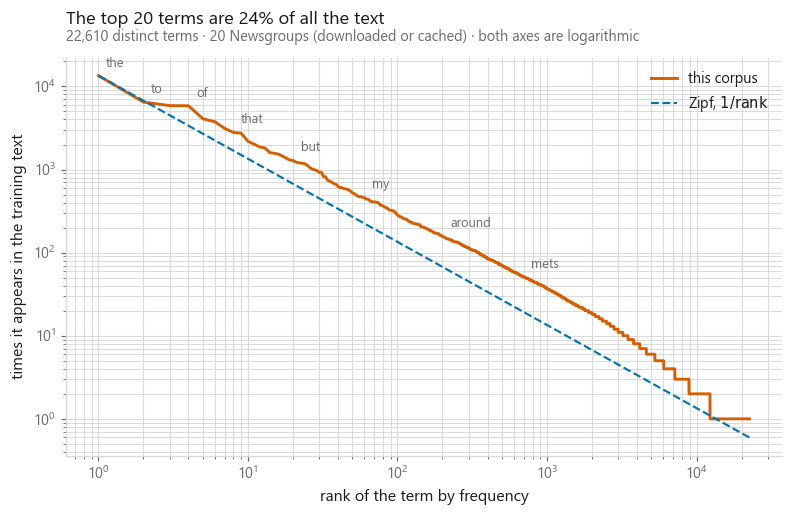

In [6]:
ranks = np.arange(1, len(order) + 1)
freqs = term_counts[order]

fig, ax = plt.subplots(figsize=(8.4, 4.7))
ax.loglog(ranks, freqs, color=style.HIGHLIGHT, lw=1.9, label="this corpus")
ax.loglog(ranks, freqs[0] / ranks, color=style.PALETTE[0], ls="--", lw=1.4,
          label=r"Zipf, $1/\mathrm{rank}$")

for r in [1, 2, 4, 8, 20, 60, 200, 700]:
    if r <= len(order):
        ax.annotate(vocab[order[r - 1]], (r, freqs[r - 1]),
                    textcoords="offset points", xytext=(5, 6),
                    fontsize=8.5, color=style.MUTED)

ax.set_xlabel("rank of the term by frequency")
ax.set_ylabel("times it appears in the training text")
ax.grid(which="both", visible=True)
ax.legend()
style.title(ax,
            f"The top 20 terms are {term_counts[order[:20]].sum() / total_tokens:.0%} "
            f"of all the text",
            f"{len(order):,} distinct terms · {SOURCE} · both axes are logarithmic")
style.save(fig, FIG / "fig-01-zipf.png")

print(f"rank 1   : '{vocab[order[0]]}' appears {freqs[0]:,} times")
print(f"rank 100 : '{vocab[order[99]]}' appears {freqs[99]:,} times")
print(f"terms appearing exactly once: {(term_counts == 1).sum():,} "
      f"({(term_counts == 1).mean():.0%} of the vocabulary)")

### Why raw counts are a bad feature

The words at the top of that curve appear in nearly every document of every
class. They take the largest values in every row, so any distance or dot product
between two documents is dominated by them, and they carry no information about
which class the document belongs to.

The table below puts that side by side: the commonest terms against terms that
appear often enough to be useful but only in part of the corpus. Compare the
per-class columns.

In [7]:
n_docs = X_count.shape[0]
useful_band = (doc_counts >= max(5, int(0.01 * n_docs))) & (doc_counts <= 0.12 * n_docs)
distinctive = [i for i in order if useful_band[i]][:6]
selection = list(order[:6]) + distinctive

block = X_count[:, selection].toarray() > 0
rows = []
for column, term_index in enumerate(selection):
    row = {"term": vocab[term_index],
           "kind": "commonest" if column < 6 else "middling",
           "count": int(term_counts[term_index]),
           "in % of docs": f"{doc_counts[term_index] / n_docs:.0%}"}
    for class_index, label in enumerate(LABELS):
        row[label] = f"{block[y_train == class_index, column].mean():.0%}"
    rows.append(row)

print("share of documents in each class that contain the term\n")
print(pd.DataFrame(rows).to_string(index=False))

share of documents in each class that contain the term

    term      kind  count in % of docs graphics baseball space
     the commonest  13469          88%      82%      89%   91%
      to commonest   6475          75%      75%      71%   79%
     and commonest   5870          69%      68%      68%   72%
      of commonest   5847          68%      65%      61%   78%
      in commonest   4080          65%      62%      65%   70%
      is commonest   3756          60%      60%      54%   65%
   image  middling    516           6%      15%       0%    3%
     edu  middling    479           9%      10%       7%    8%
    data  middling    445           6%       6%       1%   12%
    nasa  middling    415           7%       2%       0%   19%
graphics  middling    413           8%      24%       0%    1%
 program  middling    357          10%      16%       0%   12%


The commonest terms sit at roughly the same percentage in all three classes.
They are pure noise for the classifier, they are the largest numbers in the
matrix, and something has to be done about them.

## 3. TF-IDF, derived by hand

The fix is to weight each count by how unusual the term is across the corpus.
A term in every document tells you nothing, so its weight should go to about
zero. A term in a handful of documents is worth a lot when it fires.

Write $\mathrm{tf}(t, d)$ for the number of times term $t$ appears in document
$d$, $\mathrm{df}(t)$ for the number of documents containing $t$, and $n$ for the
number of documents. scikit-learn's default definition, with smoothing on, is

$$\mathrm{idf}(t) = \ln\!\left(\frac{1 + n}{1 + \mathrm{df}(t)}\right) + 1$$

$$w(t, d) = \mathrm{tf}(t, d) \times \mathrm{idf}(t)$$

and then every row is scaled to unit length,

$$\mathrm{tfidf}(t, d) = \frac{w(t, d)}{\sqrt{\sum_{t'} w(t', d)^2}}$$

Three details in that formula are choices rather than laws, and they explain
gaps between textbooks:

The $+1$ inside the log is smoothing, as if one extra document contained every
term. It stops division by zero for a term the vectoriser knows but the corpus
does not contain, which happens when you pass a fixed vocabulary.

The $+1$ outside the log stops a term that appears in every document from
getting weight exactly zero. With $\mathrm{df} = n$ the log is 0 and the idf is
1, so the term survives with its raw count rather than vanishing.

The L2 row normalisation is why a long document does not automatically beat a
short one. Every document ends up as a point on the unit sphere, and the dot
product between two rows becomes cosine similarity.

Here it is in numpy on four sentences, then the same thing from
`TfidfVectorizer`.

In [8]:
toy = [
    "the pitcher threw a fastball",
    "the pitcher threw the ball to the catcher",
    "the rocket engine burned for two minutes",
    "the rocket carried a camera",
]

toy_counts = CountVectorizer()
tf = toy_counts.fit_transform(toy).toarray().astype(float)
toy_terms = toy_counts.get_feature_names_out()

n = tf.shape[0]
df = (tf > 0).sum(axis=0)
idf = np.log((1 + n) / (1 + df)) + 1.0
weighted = tf * idf
manual = weighted / np.linalg.norm(weighted, axis=1, keepdims=True)

toy_tfidf = TfidfVectorizer()
library = toy_tfidf.fit_transform(toy).toarray()

assert list(toy_tfidf.get_feature_names_out()) == list(toy_terms)

print(pd.DataFrame({
    "term": toy_terms,
    "tf in doc 0": tf[0].astype(int),
    "df": df,
    "my idf": idf.round(4),
    "sklearn idf": toy_tfidf.idf_.round(4),
    "my tfidf, doc 0": manual[0].round(4),
    "sklearn, doc 0": library[0].round(4),
}).to_string(index=False))

print(f"\nlargest disagreement on idf        : {np.abs(idf - toy_tfidf.idf_).max():.2e}")
print(f"largest disagreement on the matrix : {np.abs(manual - library).max():.2e}")
print(f"identical to floating point        : {np.allclose(manual, library)}")

    term  tf in doc 0  df  my idf  sklearn idf  my tfidf, doc 0  sklearn, doc 0
    ball            0   1  1.9163       1.9163           0.0000          0.0000
  burned            0   1  1.9163       1.9163           0.0000          0.0000
  camera            0   1  1.9163       1.9163           0.0000          0.0000
 carried            0   1  1.9163       1.9163           0.0000          0.0000
 catcher            0   1  1.9163       1.9163           0.0000          0.0000
  engine            0   1  1.9163       1.9163           0.0000          0.0000
fastball            1   1  1.9163       1.9163           0.6305          0.6305
     for            0   1  1.9163       1.9163           0.0000          0.0000
 minutes            0   1  1.9163       1.9163           0.0000          0.0000
 pitcher            1   2  1.5108       1.5108           0.4971          0.4971
  rocket            0   2  1.5108       1.5108           0.0000          0.0000
     the            1   4  1.0000       

Read the `df` column against `my idf`. The word `the` is in all four sentences,
its idf lands at 1, and it survives only as its raw count before normalisation
scales it down. Words in one sentence get the largest weight. Nothing in the
library is doing anything the four lines of numpy above did not do.

The same check on the real corpus, where the matrix has thousands of columns and
I compute one row by hand.

In [9]:
count_full = CountVectorizer(min_df=2)
tfidf_full = TfidfVectorizer(min_df=2)
C = count_full.fit_transform(docs_train)
T = tfidf_full.fit_transform(docs_train)

assert list(count_full.get_feature_names_out()) == list(tfidf_full.get_feature_names_out())

n_full = C.shape[0]
df_full = np.asarray((C > 0).sum(axis=0)).ravel()
idf_full = np.log((1 + n_full) / (1 + df_full)) + 1.0

pick = int(np.argmax(np.asarray(C.sum(axis=1)).ravel()))  # longest document, no empty-row risk
row = C[pick].toarray().ravel().astype(float) * idf_full
row /= np.linalg.norm(row)

print(f"checking document {pick} of {n_full:,}, {int(C[pick].sum())} tokens")
print(f"largest disagreement on idf        : {np.abs(idf_full - tfidf_full.idf_).max():.2e}")
print(f"largest disagreement on that row   : {np.abs(row - T[pick].toarray().ravel()).max():.2e}")

heaviest = np.argsort(row)[::-1][:8]
print("\nthe eight heaviest terms in that document:")
print(pd.DataFrame({
    "term": count_full.get_feature_names_out()[heaviest],
    "count": C[pick].toarray().ravel()[heaviest],
    "idf": idf_full[heaviest].round(3),
    "tfidf": row[heaviest].round(4),
}).to_string(index=False))

checking document 1415 of 1,651, 8921 tokens
largest disagreement on idf        : 0.00e+00
largest disagreement on that row   : 3.33e-16

the eight heaviest terms in that document:
 term  count   idf  tfidf
 jpeg    232 5.191 0.5912
  the    362 1.132 0.2011
  gif     91 4.367 0.1951
image    100 3.815 0.1873
  you    190 1.942 0.1812
 file     85 3.910 0.1632
   is    200 1.509 0.1482
   to    226 1.286 0.1427


### What the reweighting does to the vocabulary

Sum each column of the count matrix and you get the words the corpus uses most.
Sum each column of the TF-IDF matrix and you get the words that do the most work
distinguishing documents. They are not the same list.

terms in both top-15 lists: 14 -> ['and', 'be', 'for', 'have', 'in', 'is', 'it', 'of', 'on', 'that', 'the', 'this', 'to', 'you']
only in the count list    : ['are']
only in the TF-IDF list   : ['was']


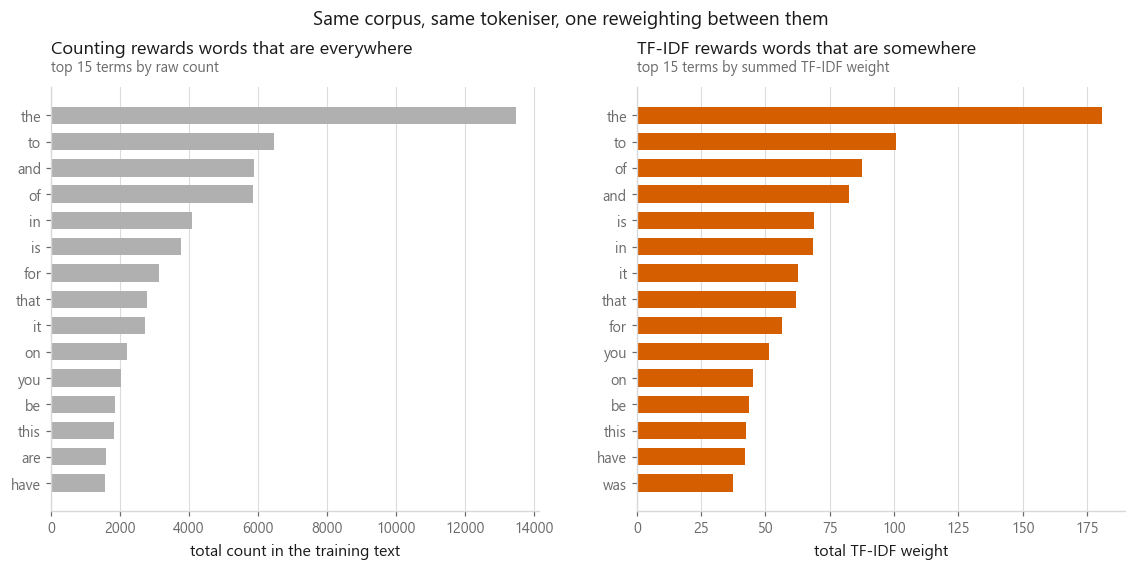

In [10]:
tfidf_all = TfidfVectorizer()
T_all = tfidf_all.fit_transform(docs_train)
assert list(tfidf_all.get_feature_names_out()) == list(vocab)

tfidf_mass = np.asarray(T_all.sum(axis=0)).ravel()
top_count = order[:15]
top_tfidf = np.argsort(tfidf_mass)[::-1][:15]

fig, axes = plt.subplots(1, 2, figsize=(12.6, 5.0))

axes[0].barh([vocab[i] for i in top_count][::-1], term_counts[top_count][::-1],
             color=style.NEUTRAL, height=0.66)
axes[0].set_xlabel("total count in the training text")
style.title(axes[0], "Counting rewards words that are everywhere",
            "top 15 terms by raw count")

axes[1].barh([vocab[i] for i in top_tfidf][::-1], tfidf_mass[top_tfidf][::-1],
             color=style.HIGHLIGHT, height=0.66)
axes[1].set_xlabel("total TF-IDF weight")
style.title(axes[1], "TF-IDF rewards words that are somewhere",
            "top 15 terms by summed TF-IDF weight")

for ax in axes:
    ax.grid(axis="y", visible=False)
    ax.grid(axis="x", visible=True)

fig.suptitle("Same corpus, same tokeniser, one reweighting between them",
             x=0.5, y=1.02, fontsize=12.5, color=style.INK)
style.save(fig, FIG / "fig-02-count-vs-tfidf.png")

shared = set(vocab[top_count]) & set(vocab[top_tfidf])
print(f"terms in both top-15 lists: {len(shared)} -> {sorted(shared)}")
print(f"only in the count list    : {sorted(set(vocab[top_count]) - shared)}")
print(f"only in the TF-IDF list   : {sorted(set(vocab[top_tfidf]) - shared)}")

## 4. n-grams and the practical dials

### What word order buys you

The bag of words throws away order, and here is the cheapest possible proof that
order sometimes matters. Two sentences, same words, opposite meaning.

In [11]:
pair = ["the player hit the ball", "the ball hit the player"]

unigrams = CountVectorizer(ngram_range=(1, 1)).fit_transform(pair).toarray()
bigrams = CountVectorizer(ngram_range=(2, 2))
bigram_matrix = bigrams.fit_transform(pair).toarray()

print("unigram vectors identical:", np.array_equal(unigrams[0], unigrams[1]))
print("bigram vectors identical :", np.array_equal(bigram_matrix[0], bigram_matrix[1]))
print("\nbigrams found:", list(bigrams.get_feature_names_out()))

negation = ["the rendering is good", "the rendering is not good"]
neg_uni = CountVectorizer().fit(negation)
neg_bi = CountVectorizer(ngram_range=(1, 2)).fit(negation)
print(f"\n'not good' as a unigram feature: {'not good' in neg_uni.vocabulary_}")
print(f"'not good' as a bigram feature : {'not good' in neg_bi.vocabulary_}")

unigram vectors identical: True
bigram vectors identical : False

bigrams found: ['ball hit', 'hit the', 'player hit', 'the ball', 'the player']

'not good' as a unigram feature: False
'not good' as a bigram feature : True


`ngram_range=(1, 2)` keeps every single word and every adjacent pair. That
recovers negation (`not good`), fixed phrases (`home run`, `low earth`), and
names that mean nothing split up. The price is the column count, which grows by
roughly an order of magnitude, because most pairs of words occur once and never
again.

Here are the bigrams each class leans on hardest, by mean TF-IDF weight within
the class.

In [12]:
bigram_vec = TfidfVectorizer(ngram_range=(2, 2), min_df=3)
B = bigram_vec.fit_transform(docs_train)
bigram_terms = bigram_vec.get_feature_names_out()

top_by_class = {}
for class_index, label in enumerate(LABELS):
    mass = np.asarray(B[np.flatnonzero(y_train == class_index)].mean(axis=0)).ravel()
    top_by_class[label] = bigram_terms[np.argsort(mass)[::-1][:10]]

print(f"{B.shape[1]:,} bigrams survive min_df=3, against "
      f"{len(vocab):,} unigrams with no filter at all\n")
print(pd.DataFrame(top_by_class).to_string(index=False))

12,264 bigrams survive min_df=3, against 22,610 unigrams with no filter at all

   graphics   baseball    space
     of the     in the   of the
     in the     of the   in the
     if you     to the   on the
looking for     on the   to the
      it is    for the  for the
     on the  this year from the
    for the  last year    to be
 in advance      to be that the
   would be the braves   if you
     to the     he was  and the


### The dials that matter

Three arguments control the size of the matrix, and they do different jobs.

`min_df` drops terms appearing in fewer than this many documents. It is the one
that matters, because Zipf guarantees a long tail of terms seen once, and a term
seen once cannot generalise — it can only be memorised.

`max_df` drops terms appearing in more than this fraction of documents. This is
a stop list derived from your own corpus instead of from a fixed English list.

`max_features` keeps the $k$ commonest terms and nothing else. A hard ceiling
for when memory is the constraint rather than accuracy.

In [13]:
dial_rows = []
for m in [1, 2, 3, 5, 10, 25]:
    v = CountVectorizer(min_df=m)
    Xm = v.fit_transform(docs_train)
    dial_rows.append({
        "min_df": m,
        "terms": Xm.shape[1],
        "non-zeros": Xm.nnz,
        "density %": round(100 * Xm.nnz / (Xm.shape[0] * Xm.shape[1]), 3),
        "tokens kept %": round(100 * int(Xm.sum()) / total_tokens, 2),
    })
dials = pd.DataFrame(dial_rows)
print(dials.to_string(index=False))

rank_of = {term: i for i, term in enumerate(vocab)}
capped = CountVectorizer(max_df=0.5).fit(docs_train)
dropped = sorted(set(vocab) - set(capped.get_feature_names_out()),
                 key=lambda w: -term_counts[rank_of[w]])
print(f"\nmax_df=0.5 drops {len(dropped)} terms: {dropped[:12]}")
if dropped:
    print(f"of those, {sum(w in stop_list for w in dropped) / len(dropped):.0%} "
          f"are already on sklearn's English stop list")

for k in [1000, 5000, 20000]:
    v = CountVectorizer(max_features=k)
    Xk = v.fit_transform(docs_train)
    print(f"max_features={k:>6}: {Xk.shape[1]:,} terms, "
          f"{int(Xk.sum()) / total_tokens:.1%} of all tokens kept")

 min_df  terms  non-zeros  density %  tokens kept %
      1  22610     152815      0.409         100.00
      2  10683     140888      0.799          94.47
      3   7442     134406      1.094          91.35
      5   4770     125342      1.592          86.87
     10   2562     110929      2.623          79.56
     25    984      87414      5.381          66.53



max_df=0.5 drops 9 terms: ['the', 'to', 'and', 'of', 'in', 'is', 'for', 'that', 'it']
of those, 100% are already on sklearn's English stop list


max_features=  1000: 1,000 terms, 67.7% of all tokens kept


max_features=  5000: 5,000 terms, 88.2% of all tokens kept


max_features= 20000: 20,000 terms, 99.0% of all tokens kept


min_df=2 matrix: 1,651 x 10,683 = 17,637,633 cells, 140,888 of them stored
dense float64 would need 141.1 MB; sparse storage needs about 1.7 MB


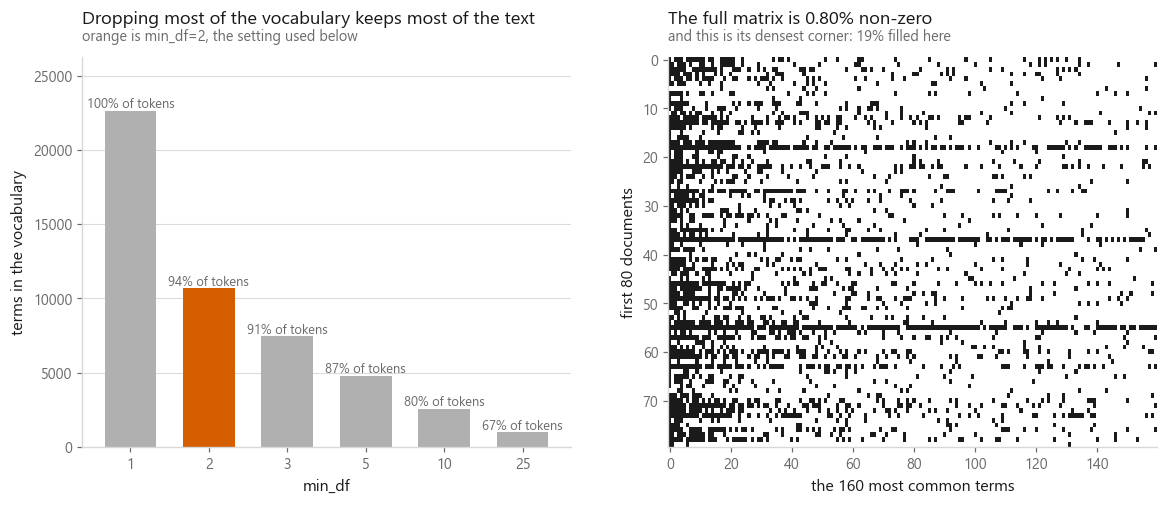

In [14]:
from matplotlib.colors import ListedColormap

grid = [1, 2, 3, 5, 10, 25]
fig, axes = plt.subplots(1, 2, figsize=(12.6, 4.6))

bars = axes[0].bar([str(m) for m in grid], dials["terms"],
                   color=[style.HIGHLIGHT if m == 2 else style.NEUTRAL for m in grid],
                   width=0.66)
for rect, value, kept in zip(bars, dials["terms"], dials["tokens kept %"]):
    axes[0].text(rect.get_x() + rect.get_width() / 2, value, f"{kept:.0f}% of tokens",
                 ha="center", va="bottom", fontsize=8.5, color=style.MUTED)
axes[0].set_xlabel("min_df")
axes[0].set_ylabel("terms in the vocabulary")
axes[0].set_ylim(0, dials["terms"].max() * 1.16)
style.title(axes[0], "Dropping most of the vocabulary keeps most of the text",
            "orange is min_df=2, the setting used below")

C2 = CountVectorizer(min_df=2).fit_transform(docs_train)
common_columns = np.argsort(np.asarray(C2.sum(axis=0)).ravel())[::-1][:160]
patch = C2[:80].toarray()[:, common_columns] > 0
density = C2.nnz / (C2.shape[0] * C2.shape[1])

axes[1].imshow(patch, cmap=ListedColormap(["#ffffff", style.INK]),
               aspect="auto", interpolation="nearest")
axes[1].grid(False)
axes[1].set_xlabel("the 160 most common terms")
axes[1].set_ylabel("first 80 documents")
style.title(axes[1], f"The full matrix is {density:.2%} non-zero",
            f"and this is its densest corner: {patch.mean():.0%} filled here")

style.save(fig, FIG / "fig-03-sparsity-and-min-df.png")

print(f"min_df=2 matrix: {C2.shape[0]:,} x {C2.shape[1]:,} = "
      f"{C2.shape[0] * C2.shape[1]:,} cells, {C2.nnz:,} of them stored")
print(f"dense float64 would need {C2.shape[0] * C2.shape[1] * 8 / 1e6:.1f} MB; "
      f"sparse storage needs about {C2.nnz * 12 / 1e6:.1f} MB")

That matrix is almost entirely zeros, which is why every text vectoriser in
scikit-learn returns a sparse matrix and why the linear models accept one. A
dense array of the same shape wastes most of its memory storing the fact that a
document did not contain a word.

The panel on the right is the *densest* corner of the matrix — the most common
terms in the earliest documents. Everything outside that corner is emptier.

## 5. A classifier on top

Four setups, same logistic regression on each, fitted on the training documents
and scored once on the held-out test documents.

Raw counts with no filtering is the naive baseline. Adding a stop list and
`min_df=2` is the cheap cleanup. TF-IDF is the reweighting from section 3.
TF-IDF with bigrams adds word order back at a cost in columns.

In [15]:
import time

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

setups = {
    "counts, no filtering": CountVectorizer(),
    "counts, stop words + min_df=2": CountVectorizer(stop_words="english", min_df=2),
    "TF-IDF, stop words + min_df=2": TfidfVectorizer(stop_words="english", min_df=2),
    "TF-IDF + bigrams": TfidfVectorizer(stop_words="english", min_df=2, ngram_range=(1, 2)),
}

records = []
for name, vectoriser in setups.items():
    started = time.perf_counter()
    Xtr = vectoriser.fit_transform(docs_train)
    Xte = vectoriser.transform(docs_test)
    # Unscaled counts make lbfgs work harder than L2-normalised TF-IDF does.
    model = LogisticRegression(max_iter=2000, random_state=SEED).fit(Xtr, y_train)
    predicted = model.predict(Xte)
    records.append({
        "setup": name,
        "features": Xtr.shape[1],
        "density %": round(100 * Xtr.nnz / (Xtr.shape[0] * Xtr.shape[1]), 3),
        "accuracy": round(accuracy_score(y_test, predicted), 4),
        "macro F1": round(f1_score(y_test, predicted, average="macro"), 4),
        "seconds": round(time.perf_counter() - started, 1),
    })

results = pd.DataFrame(records)
print(results.to_string(index=False))

best = results.loc[results["accuracy"].idxmax()]
worst = results.loc[results["accuracy"].idxmin()]
print(f"\nbest : {best['setup']} at {best['accuracy']:.4f}")
print(f"worst: {worst['setup']} at {worst['accuracy']:.4f}")
print(f"gap  : {best['accuracy'] - worst['accuracy']:+.4f} accuracy")
if worst["accuracy"] < 1.0:
    change = (1 - best["accuracy"]) / (1 - worst["accuracy"]) - 1
    print(f"       {change:+.1%} change in error rate from worst to best")

                        setup  features  density %  accuracy  macro F1  seconds
         counts, no filtering     22610      0.409    0.8676    0.8677      1.9
counts, stop words + min_df=2     10396      0.545    0.8941    0.8941      0.7
TF-IDF, stop words + min_df=2     10396      0.545    0.9233    0.9236      0.7
             TF-IDF + bigrams     20790      0.354    0.9224    0.9226      1.3

best : TF-IDF, stop words + min_df=2 at 0.9233
worst: counts, no filtering at 0.8676
gap  : +0.0557 accuracy
       -42.1% change in error rate from worst to best


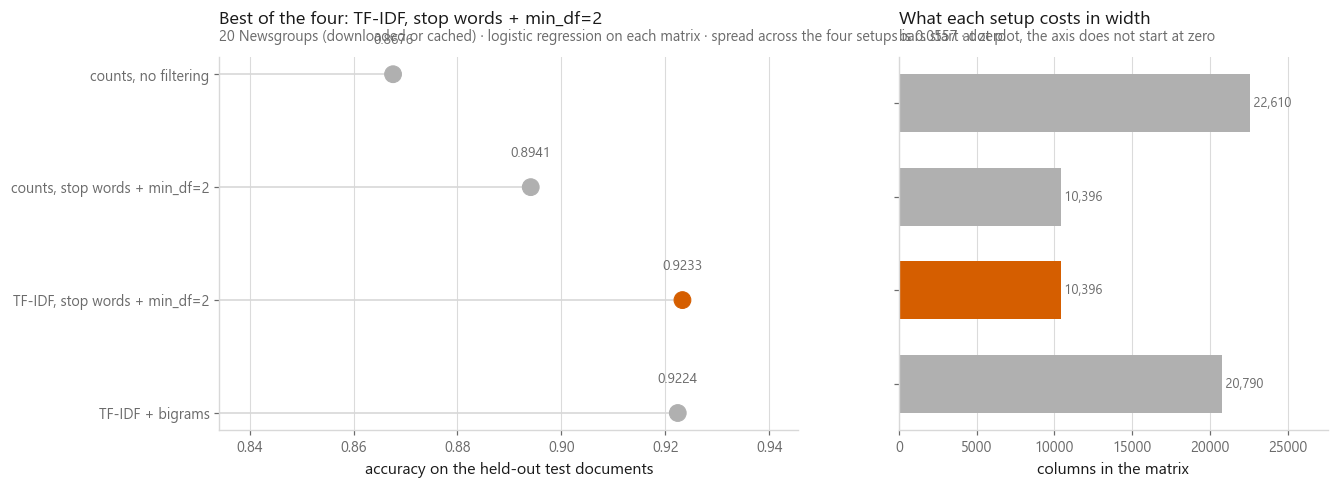

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13.0, 4.4),
                         gridspec_kw={"width_ratios": [1.35, 1]})

names = list(results["setup"])[::-1]
scores = list(results["accuracy"])[::-1]
best_index = int(np.argmax(scores))
colours = [style.HIGHLIGHT if i == best_index else style.NEUTRAL for i in range(len(scores))]

span = max(scores) - min(scores)
left = min(scores) - max(span * 0.6, 0.01)
right = max(scores) + max(span * 0.4, 0.008)
for i, value in enumerate(scores):
    axes[0].plot([left, value], [i, i], color=style.RULE, lw=1.1, zorder=0)
axes[0].scatter(scores, range(len(scores)), s=120, c=colours,
                marker=style.MARKERS[0], zorder=3)
for i, value in enumerate(scores):
    axes[0].text(value, i + 0.24, f"{value:.4f}", ha="center", va="bottom",
                 fontsize=9, color=style.MUTED)
axes[0].set_yticks(range(len(names)), names)
axes[0].set_xlim(left, right)
axes[0].set_xlabel("accuracy on the held-out test documents")
axes[0].grid(axis="y", visible=False)
axes[0].grid(axis="x", visible=True)
style.title(axes[0], f"Best of the four: {best['setup']}",
            f"{SOURCE} · logistic regression on each matrix · spread across the four "
            f"setups is {span:.4f} · dot plot, the axis does not start at zero")

feature_counts = list(results["features"])[::-1]
axes[1].barh(range(len(names)), feature_counts, color=colours, height=0.62)
for i, value in enumerate(feature_counts):
    axes[1].text(value, i, f" {value:,}", va="center", fontsize=8.5, color=style.MUTED)
axes[1].set_yticks(range(len(names)), ["" for _ in names])
axes[1].set_xlim(0, max(feature_counts) * 1.22)
axes[1].set_xlabel("columns in the matrix")
axes[1].grid(axis="y", visible=False)
axes[1].grid(axis="x", visible=True)
style.title(axes[1], "What each setup costs in width", "bars start at zero")

style.save(fig, FIG / "fig-04-classifier-comparison.png")

Read the printed table rather than the shape of the bars, and read the two
columns together. The interesting comparison is how much accuracy each setup
buys against how many columns it needs to buy it.

What I expected before running this: filtering would help a little, TF-IDF would
help more, and bigrams would pay for their width or not depending on the corpus.
The printed table is the answer, and the bigram row is the one I would never
assume in advance. On topic classification the words alone usually carry the
topic, and the extra columns are mostly noise the model has to regularise away.
On sentiment, where `not good` and `good` mean opposite things, the same
experiment tends to come out differently.

One habit worth keeping from this section: the vectoriser is fitted on training
data only. Fitting it on the full corpus lets the test documents influence the
vocabulary and the idf weights, and the score you get back is optimistic. In
practice put the vectoriser and the model in a `Pipeline` so cross-validation
cannot get this wrong on your behalf.

## Cheat sheet

| | |
|---|---|
| **Bag of words** | Fix a vocabulary of $V$ terms, count occurrences, get an $n \times V$ matrix. Word order is discarded |
| **`CountVectorizer` defaults** | Lowercases, tokenises on `\b\w\w+\b` so single letters and punctuation vanish, no stemming, no stop words |
| **TF-IDF** | $\mathrm{tf} \times \left[\ln\frac{1+n}{1+\mathrm{df}} + 1\right]$, then L2-normalise each row. Common terms shrink, rare terms grow, document length stops mattering |
| **Stemming vs lemmatising** | Stemming chops suffixes by rule and can return non-words; lemmatising uses a dictionary and returns real base forms. Neither is needed for topic classification |
| **`min_df`** | The dial that matters. `min_df=2` removes the terms seen once, which is most of the vocabulary and very little of the text |
| **`max_df`** | A stop list derived from your corpus. Usually better than a fixed English list |
| **`max_features`** | A hard ceiling on columns, for when memory is the binding constraint |
| **n-grams** | `ngram_range=(1, 2)` recovers negation and fixed phrases. Costs roughly an order of magnitude in columns |
| **Sparsity** | Keep the matrix sparse. Linear models, naive Bayes and SGD all accept it; dense arrays and tree models generally do not want it |
| **Fit on train only** | Vocabulary and idf weights are fitted parameters. Use a `Pipeline` |
| **Next** | [Word embeddings](../02-word-embeddings/), which give up the one-column-per-word idea entirely |

## What to remember

1. A bag of words is a count matrix with word order thrown away, and on topic
   classification that loss is cheap.
2. Word frequencies follow Zipf's law, so a handful of terms dominate every row
   and a huge tail of terms appears once.
3. TF-IDF multiplies each count by $\ln\frac{1+n}{1+\mathrm{df}} + 1$ and
   normalises the row. It is four lines of numpy, and the printed check above
   shows the library does exactly that.
4. `min_df` is the dial worth turning first. It cuts the vocabulary hard and the
   token count barely.
5. Bigrams recover the meaning that lives between adjacent words, at roughly ten
   times the columns. Measure before you keep them.
6. Fit the vectoriser on the training documents only. The vocabulary and the idf
   weights are parameters like any other.

---

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com)

Next: [09-02 Word embeddings: Word2Vec and GloVe](../02-word-embeddings/) ·
Back to [the curriculum](../../CURRICULUM.md)

`#MachineLearning` `#NLP` `#TFIDF` `#BagOfWords` `#TextMining`
`#Python` `#ScikitLearn` `#DataScience` `#MLTutorial` `#FeatureEngineering`